# Employee Attrition — Data Pipeline

See `ARCHITECTURE.md` in this folder first — it has the pipeline
diagram and a full list of what's deliberately wrong with each column
in `employee_attrition_raw.csv`. This notebook runs that pipeline,
stage by stage, with a real chart and real numbers at every step.

`706` rows, `12` columns, one target (`Attrition`) — a synthetic
dataset (random seed `42`, reproducible), built so every technique from
`04` through `19` has something real to fix.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    FunctionTransformer,
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    LabelEncoder,
)

## 0. Load & First Look

In [2]:
dataset = pd.read_csv("employee_attrition_raw.csv")
dataset.head()

,EmployeeID,Age,Gender,Department,Education,PriorCompanies,YearsAtCompany,MonthlyIncome,DistanceFromHome,OverTime,PerformanceRating,Attrition
0,E0390,24.0,Male,Sales,Bachelors,1,1.2,8576.0,3.0,No,Medium,No
1,E0122,36.0,Male,Marketing,High School,1,29.3,4869.0,1.1,No,Medium,No
2,E0523,46.0,Female,Sales,Bachelors,1,4.6,1889.0,13.5,Yes,Medium,Yes
3,E0310,49.0,Male,Sales,Masters,3+,1.2,19591.0,18.8,Yes,Low,No
4,E0647,40.0,Female,Engineering,PhD,0,10.1,14041.0,NaN,NO,Medium,No


In [3]:
dataset.shape

(706, 12)

In [4]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 706 entries, 0 to 705
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   EmployeeID         706 non-null    str    
 1   Age                685 non-null    float64
 2   Gender             692 non-null    str    
 3   Department         699 non-null    str    
 4   Education          685 non-null    str    
 5   PriorCompanies     692 non-null    str    
 6   YearsAtCompany     685 non-null    float64
 7   MonthlyIncome      678 non-null    float64
 8   DistanceFromHome   692 non-null    float64
 9   OverTime           699 non-null    str    
 10  PerformanceRating  685 non-null    str    
 11  Attrition          706 non-null    str    
dtypes: float64(4), str(8)
memory usage: 66.3 KB


`706` rows, `12` columns. `EmployeeID` is just an identifier — no
predictive value, so it gets dropped from the final table. Everything
else either needs cleaning (missing values, messy text, wrong dtype,
outliers, skew) before it's usable, or is already the target.

In [5]:
dataset["Attrition"].value_counts()

Attrition
No     500
Yes    206
Name: count, dtype: int64

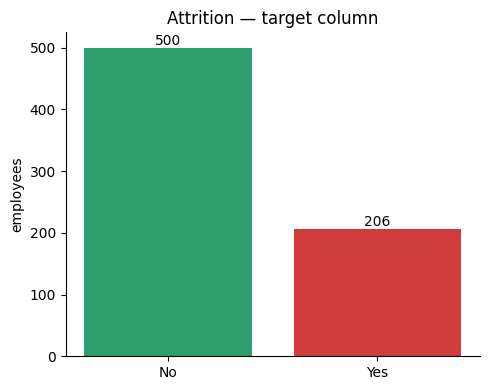

In [6]:
plt.figure(figsize=(5, 4))
counts = dataset["Attrition"].value_counts()
bars = plt.bar(counts.index, counts.values, color=["#2f9e6f", "#d03b3b"])
plt.title("Attrition — target column")
plt.ylabel("employees")
for b in bars:
    plt.text(b.get_x() + b.get_width() / 2, b.get_height() + 5,
              str(int(b.get_height())), ha="center")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

`500` stayed, `206` left — about `71%` / `29%`. Less lopsided than
`loans.csv`'s `82%`/`18%` target, but still worth knowing before anyone
trains a model on this later.

## 1. Missing Values — Numbers First (`06`, `07`, `08`)

Filling the 4 numeric columns now, with the median. The categorical
columns wait until Section 3, on purpose — see `ARCHITECTURE.md` for
why.

In [7]:
dataset.isnull().sum()

EmployeeID            0
Age                  21
Gender               14
Department            7
Education            21
PriorCompanies       14
YearsAtCompany       21
MonthlyIncome        28
DistanceFromHome     14
OverTime              7
PerformanceRating    21
Attrition             0
dtype: int64

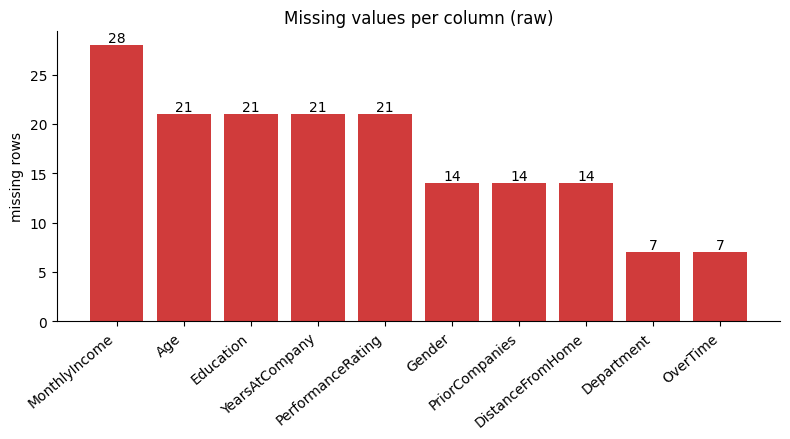

In [8]:
missing = dataset.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(8, 4.5))
bars = plt.bar(missing.index, missing.values, color="#d03b3b")
plt.title("Missing values per column (raw)")
plt.ylabel("missing rows")
plt.xticks(rotation=40, ha="right")
for b in bars:
    plt.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.3,
              str(int(b.get_height())), ha="center")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

`10` columns have gaps. `EmployeeID` and `Attrition` don't — an
identifier and the target were built with no missing values on
purpose, the same way `loans.csv`'s `CoapplicantIncome` had `0`
missing in `19`.

In [9]:
num_median_cols = ["Age", "YearsAtCompany", "MonthlyIncome", "DistanceFromHome"]

for c in num_median_cols:
    dataset[c] = dataset[c].fillna(dataset[c].median())

dataset[num_median_cols].isnull().sum()

Age                 0
YearsAtCompany      0
MonthlyIncome       0
DistanceFromHome    0
dtype: int64

All 4 numeric columns at `0` missing now. The 6 categorical columns
still have gaps — that's expected, come back to them in Section 3.

## 2. Duplicate Rows (`17`)

Unlike `loans.csv`, this dataset actually has some.

In [10]:
dataset.duplicated().sum()

np.int64(6)

In [11]:
before_dedup = dataset.shape[0]
dataset = dataset.drop_duplicates().reset_index(drop=True)
before_dedup, dataset.shape[0]

(706, 700)

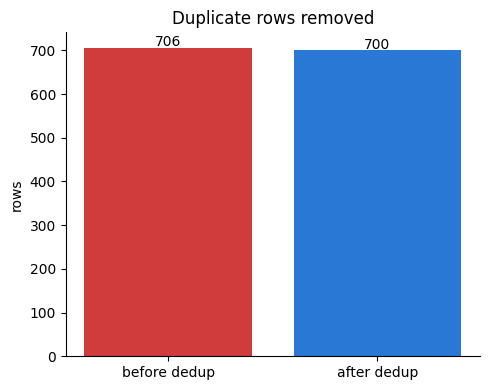

In [12]:
plt.figure(figsize=(5, 4))
bars = plt.bar(["before dedup", "after dedup"], [before_dedup, dataset.shape[0]],
                color=["#d03b3b", "#2a78d6"])
plt.ylabel("rows")
plt.title("Duplicate rows removed")
for b in bars:
    plt.text(b.get_x() + b.get_width() / 2, b.get_height() + 3,
              str(int(b.get_height())), ha="center")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

`6` exact duplicate rows found and dropped — `706 → 700`. Real
duplicates this time, not a simulated example like `17` had to build
on `loans.csv`.

## 3. Fixing Inconsistent Data (`04`, Sub-Skill #6)

`04_Data_Cleaning.MD` names this as its own sub-skill, distinct from
missing values: data that's fully *present*, just written more than
one way. `Gender` and `OverTime` both have this problem — the exact
same real value spelled with different capitalization or stray spaces.

In [13]:
dataset["Gender"].value_counts()

Gender
Male       356
Female     229
Male        23
male        21
MALE        19
FEMALE      17
female      11
Female      10
Name: count, dtype: int64

In [14]:
dataset["OverTime"].value_counts()

OverTime
No     425
Yes    184
no      25
NO      24
yes     19
YES     16
Name: count, dtype: int64

`Gender` has `8` different spellings of `2` real categories
(`"Male"`, `"male"`, `"MALE"`, `"Male "`, and the same 4 for
`"Female"`). `OverTime` has `6` spellings of `2` categories. A computer
reads `"Male"` and `"male"` as two completely different strings — it
has no idea they mean the same thing unless told.

In [15]:
messy_dummy_cols = pd.get_dummies(dataset["Gender"]).shape[1]
messy_dummy_cols

8

This is the concrete cost of skipping this step: one-hot encoding
`Gender` *right now*, before cleaning it, would create `8` columns —
one per spelling — instead of `2`. Every downstream technique
(encoding, counting, grouping) silently breaks on inconsistent text.
Fix: strip stray spaces, then standardize capitalization.

In [16]:
dataset["Gender"] = dataset["Gender"].str.strip().str.capitalize()
dataset["OverTime"] = dataset["OverTime"].str.strip().str.capitalize()

dataset["Gender"].value_counts()

Gender
Male      419
Female    267
Name: count, dtype: int64

In [17]:
dataset["OverTime"].value_counts()

OverTime
No     474
Yes    219
Name: count, dtype: int64

In [18]:
pd.get_dummies(dataset["Gender"]).shape[1]

2

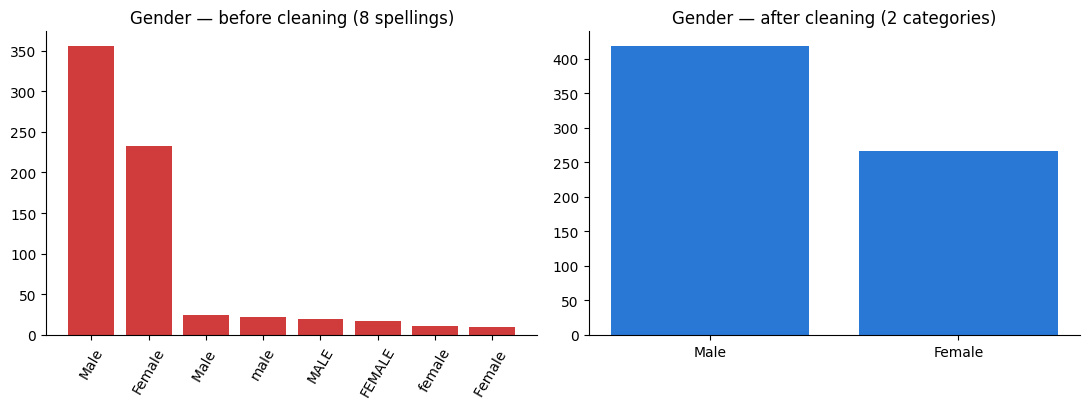

In [19]:
messy_gender = pd.read_csv("employee_attrition_raw.csv")["Gender"].value_counts()
clean_gender = dataset["Gender"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].bar(messy_gender.index, messy_gender.values, color="#d03b3b")
axes[0].set_title(f"Gender — before cleaning ({len(messy_gender)} spellings)")
axes[0].tick_params(axis="x", rotation=60)

axes[1].bar(clean_gender.index, clean_gender.values, color="#2a78d6")
axes[1].set_title(f"Gender — after cleaning ({len(clean_gender)} categories)")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

`8 → 2` columns for `Gender`, and `OverTime` is down to its real `2`
categories as well. `.str.strip()` removes leading/trailing spaces;
`.str.capitalize()` forces the first letter uppercase and the rest
lowercase, so `"MALE"`, `"male"`, and `"Male "` all land on the same
`"Male"`.

## 4. Missing Values — Categories Now (`07`)

`Gender` and `OverTime` are clean now, so it's finally safe to fill
every remaining categorical gap with the mode — no risk of the count
being split across casing variants anymore.

In [20]:
cat_mode_cols = ["Gender", "Department", "Education",
                 "PriorCompanies", "OverTime", "PerformanceRating"]

for c in cat_mode_cols:
    dataset[c] = dataset[c].fillna(dataset[c].mode()[0])

dataset.isnull().sum().sum()

np.int64(0)

`0` — every gap in the dataset is filled.

## 5. Fixing Values & Data Types (`18`)

`PriorCompanies` has the exact same shape of problem `18` fixed on
`loans.csv`'s `Dependents`: a `"3+"` bucket that isn't a number yet.

In [21]:
dataset["PriorCompanies"].unique()

<StringArray>
['1', '3+', '0', '2']
Length: 4, dtype: str

In [22]:
dataset["PriorCompanies"] = dataset["PriorCompanies"].replace("3+", "3")
dataset["PriorCompanies"] = dataset["PriorCompanies"].astype("int64")

dataset["PriorCompanies"].dtype

dtype('int64')

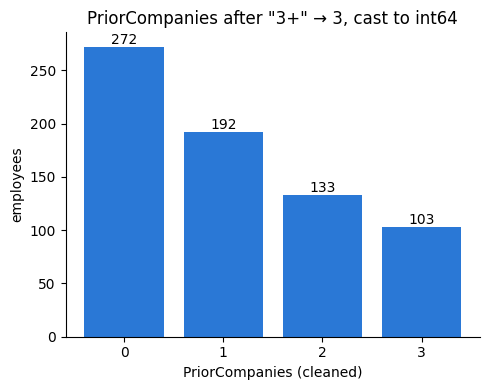

In [23]:
plt.figure(figsize=(5, 4))
counts = dataset["PriorCompanies"].value_counts().sort_index()
bars = plt.bar(counts.index.astype(str), counts.values, color="#2a78d6")
plt.xlabel("PriorCompanies (cleaned)")
plt.ylabel("employees")
plt.title('PriorCompanies after "3+" → 3, cast to int64')
for b in bars:
    plt.text(b.get_x() + b.get_width() / 2, b.get_height() + 3,
              str(int(b.get_height())), ha="center")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

`"3+"` is gone, and the column is a plain `int64` now.

## 6. Outlier Detection & Removal (`12`, `13`, `14`)

Three numeric columns checked: `Age` (a few fake ages up to `99`),
`MonthlyIncome`, and `DistanceFromHome` (both built right-skewed with
some real extreme values).

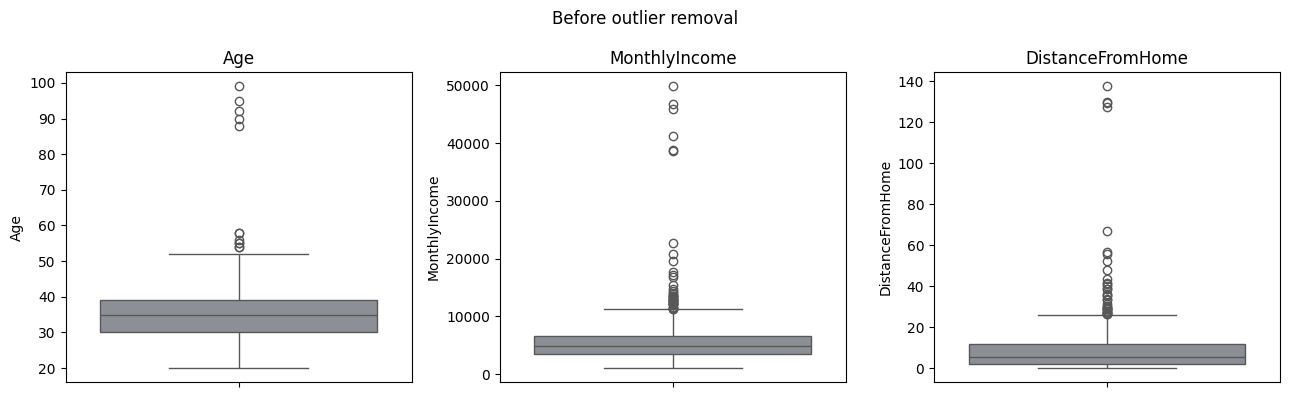

In [24]:
outlier_cols = ["Age", "MonthlyIncome", "DistanceFromHome"]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, c in zip(axes, outlier_cols):
    sns.boxplot(y=dataset[c], ax=ax, color="#8a8f98")
    ax.set_title(c)
plt.suptitle("Before outlier removal")
plt.tight_layout()
plt.show()

In [25]:
iqr_bounds = {}
for c in outlier_cols:
    q1, q3 = dataset[c].quantile(0.25), dataset[c].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    iqr_bounds[c] = (lo, hi)
    n_out = ((dataset[c] < lo) | (dataset[c] > hi)).sum()
    print(f"{c}: IQR bounds=({lo:.1f}, {hi:.1f})  outliers={n_out}")

Age: IQR bounds=(16.5, 52.5)  outliers=12
MonthlyIncome: IQR bounds=(-1109.2, 11250.8)  outliers=39
DistanceFromHome: IQR bounds=(-12.5, 26.4)  outliers=34


In [26]:
for c in outlier_cols:
    z = (dataset[c] - dataset[c].mean()) / dataset[c].std()
    n_out = (z.abs() > 3).sum()
    print(f"{c}: Z-score outliers(|z|>3)={n_out}")

Age: Z-score outliers(|z|>3)=5
MonthlyIncome: Z-score outliers(|z|>3)=9
DistanceFromHome: Z-score outliers(|z|>3)=9


Same pattern as `14` found on `loans.csv`: IQR flags more than
Z-score on every one of these skewed columns (`Age`: `12` vs `5`;
`MonthlyIncome`: `39` vs `9`; `DistanceFromHome`: `34` vs `9`) — the
mean and standard deviation Z-score relies on get stretched by the very
outliers they're supposed to catch, making the `3`-standard-deviation
bar too lenient. Using the IQR result.

In [27]:
before_rows = dataset.shape[0]

mask = pd.Series(True, index=dataset.index)
for c in outlier_cols:
    lo, hi = iqr_bounds[c]
    mask &= (dataset[c] >= lo) & (dataset[c] <= hi)

dataset = dataset[mask].copy()
before_rows, dataset.shape[0]

(700, 616)

`700 → 616` rows — `84` dropped. Add up the 3 individual outlier
counts (`12 + 39 + 34 = 85`) and it's close to `84` but not exactly
equal: only `1` row was flagged as an outlier on more than one column
at once. Almost no overlap — these three columns are catching
different extreme rows, not the same ones three times.

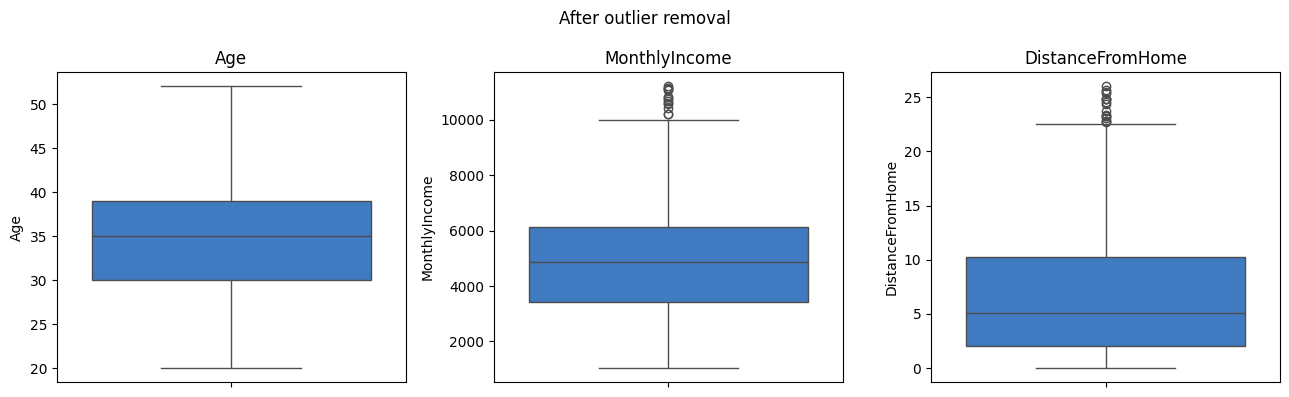

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, c in zip(axes, outlier_cols):
    sns.boxplot(y=dataset[c], ax=ax, color="#2a78d6")
    ax.set_title(c)
plt.suptitle("After outlier removal")
plt.tight_layout()
plt.show()

## 7. Fixing Skewed Shape (`19`)

Same lesson as `19_Function_Transformer.ipynb`: right-skewed money and
distance columns respond well to `log1p`.

In [29]:
skew_cols = ["MonthlyIncome", "DistanceFromHome"]
skew_before = {c: dataset[c].skew() for c in skew_cols}
skew_before

{'MonthlyIncome': np.float64(0.6832499144477358),
 'DistanceFromHome': np.float64(1.0946791576029027)}

In [30]:
log_ft = FunctionTransformer(func=np.log1p)

for c in skew_cols:
    dataset[c + "_log"] = log_ft.fit_transform(dataset[[c]])

skew_after = {c: dataset[c + "_log"].skew() for c in skew_cols}
skew_after

{'MonthlyIncome': np.float64(-0.43733459028916893),
 'DistanceFromHome': np.float64(-0.1389232654364261)}

/var/folders/07/ymtnct793nj_13sf3p9t0lqh0000gn/T/ipykernel_38049/219068399.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset[c], ax=axes[0, i], color="#8a8f98")
/var/folders/07/ymtnct793nj_13sf3p9t0lqh0000gn/T/ipykernel_38049/219068399.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplo

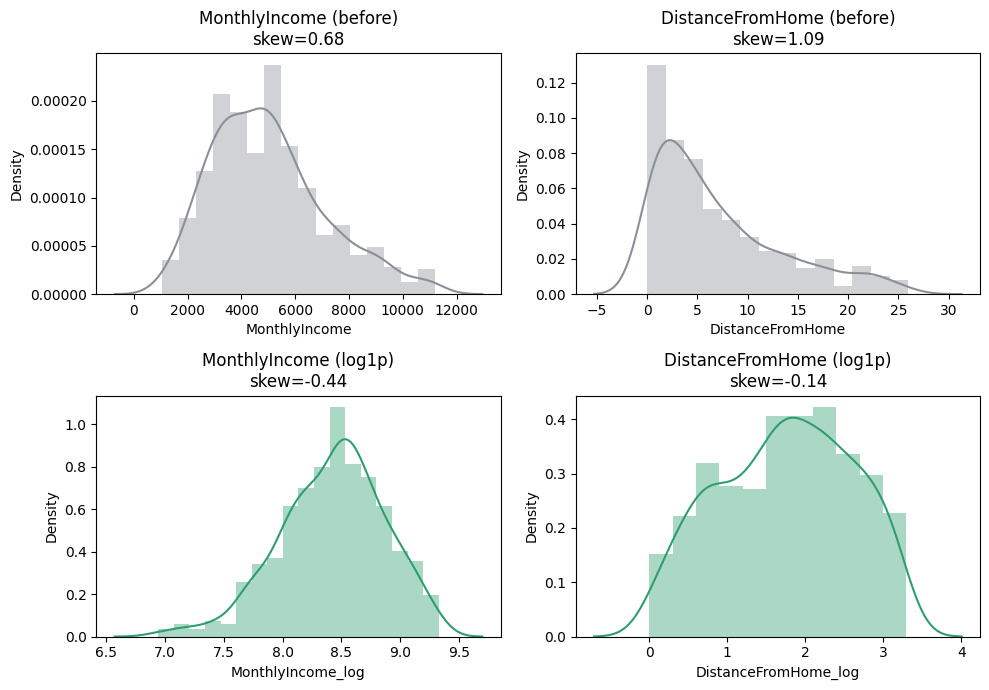

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for i, c in enumerate(skew_cols):
    sns.distplot(dataset[c], ax=axes[0, i], color="#8a8f98")
    axes[0, i].set_title(f"{c} (before)\nskew={skew_before[c]:.2f}")

    sns.distplot(dataset[c + "_log"], ax=axes[1, i], color="#2f9e6f")
    axes[1, i].set_title(f"{c} (log1p)\nskew={skew_after[c]:.2f}")

plt.tight_layout()
plt.show()

| Column | Skew before | Skew after `log1p` |
|---|---|---|
| MonthlyIncome | `0.68` | `-0.44` |
| DistanceFromHome | `1.09` | `-0.14` |

Both much closer to `0` — the same result `19` got on
`CoapplicantIncome`, on two brand-new columns.

## 8. Feature Scaling (`15`, `16`)

`StandardScaler` on the two `log1p` columns (roughly bell-shaped now,
which is what standardization suits). `MinMaxScaler` on `Age` and
`YearsAtCompany` — both naturally bounded (an age, a tenure), which is
what min-max suits.

In [32]:
log_cols = [c + "_log" for c in skew_cols]
scaled_cols = [c + "_scaled" for c in skew_cols]

scaler = StandardScaler()
dataset[scaled_cols] = scaler.fit_transform(dataset[log_cols])

dataset[scaled_cols].mean().round(3), dataset[scaled_cols].std().round(3)

(MonthlyIncome_scaled       0.0
 DistanceFromHome_scaled    0.0
 dtype: float64,
 MonthlyIncome_scaled       1.001
 DistanceFromHome_scaled    1.001
 dtype: float64)

In [33]:
mm_scaler = MinMaxScaler()
dataset[["Age_scaled", "YearsAtCompany_scaled"]] = mm_scaler.fit_transform(
    dataset[["Age", "YearsAtCompany"]]
)

dataset[["Age_scaled", "YearsAtCompany_scaled"]].min(), dataset[["Age_scaled", "YearsAtCompany_scaled"]].max()

(Age_scaled               0.0
 YearsAtCompany_scaled    0.0
 dtype: float64,
 Age_scaled               1.0
 YearsAtCompany_scaled    1.0
 dtype: float64)

/var/folders/07/ymtnct793nj_13sf3p9t0lqh0000gn/T/ipykernel_38049/2549408374.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["MonthlyIncome_log"], ax=axes[0], color="#8a8f98")
/var/folders/07/ymtnct793nj_13sf3p9t0lqh0000gn/T/ipykernel_38049/2549408374.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe57

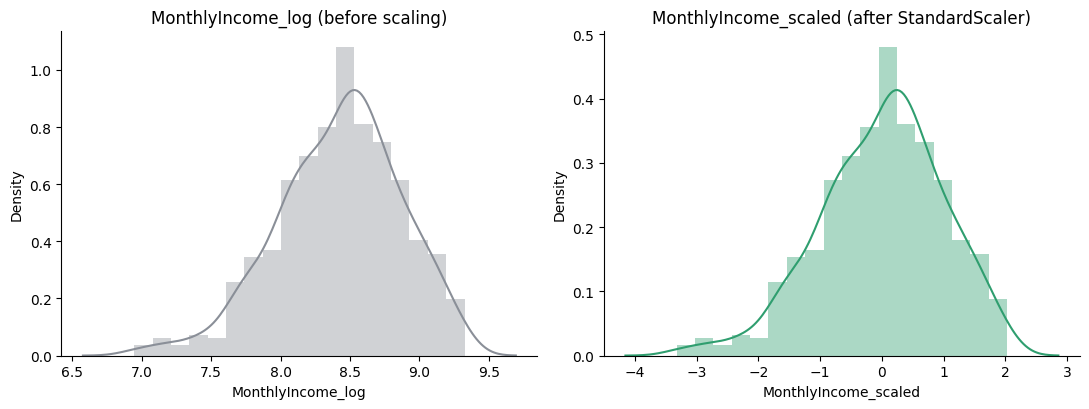

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
sns.distplot(dataset["MonthlyIncome_log"], ax=axes[0], color="#8a8f98")
axes[0].set_title("MonthlyIncome_log (before scaling)")

sns.distplot(dataset["MonthlyIncome_scaled"], ax=axes[1], color="#2f9e6f")
axes[1].set_title("MonthlyIncome_scaled (after StandardScaler)")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Same curve shape on both sides — scaling doesn't touch shape at all,
only the numbers on the x-axis. That's the difference between this
section and Section 7: `log1p` changed the **shape** (skew), and
`StandardScaler` here changes the **range** the values sit in, without
bending the curve any further.

Mean `≈ 0`, standard deviation `≈ 1` on the standardized columns; `0`
and `1` exactly on the min-max ones — checked directly, not assumed.

## 9. Encoding Categorical Variables (`09`, `10`, `11`)

| Column(s) | Kind | Encoder | Why |
|---|---|---|---|
| `Gender`, `OverTime`, `Department` | nominal — no real order | `OneHotEncoder` (`09`) | a number would invent a fake ranking |
| `Education`, `PerformanceRating` | ordinal — a real ranking exists | `OrdinalEncoder` (`11`) | let the model see the real order |
| `Attrition` | the target | `LabelEncoder` (`10`) | this is what `LabelEncoder` is for |

`PriorCompanies` doesn't appear here — it was already turned into
plain numbers in Section 5, the same reasoning `19`'s project used for
`Dependents`: its categories were digits in disguise, not real words.

In [35]:
nominal_cols = ["Gender", "OverTime", "Department"]

ohe = OneHotEncoder(drop="first", sparse_output=False)
ohe_array = ohe.fit_transform(dataset[nominal_cols])
ohe_names = ohe.get_feature_names_out(nominal_cols)

dataset[list(ohe_names)] = ohe_array.astype(int)
list(ohe_names)

['Gender_Male',
 'OverTime_Yes',
 'Department_Finance',
 'Department_HR',
 'Department_Marketing',
 'Department_Sales']

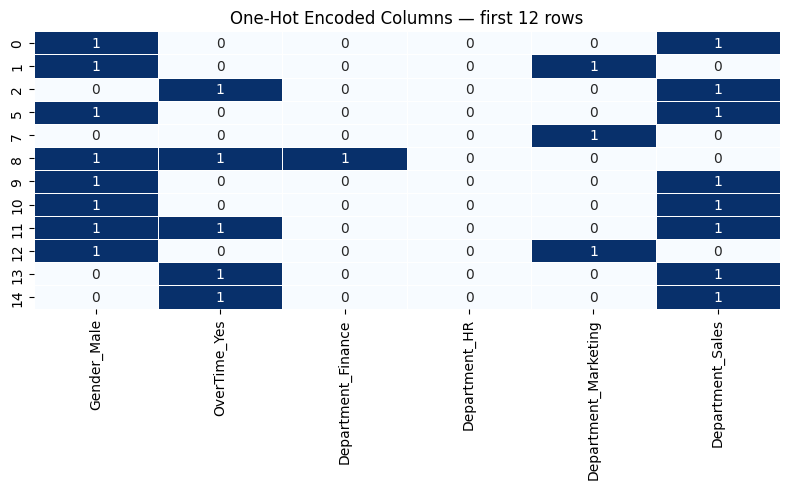

In [36]:
sample = dataset[list(ohe_names)].head(12)

plt.figure(figsize=(8, 5))
sns.heatmap(sample, annot=True, cmap="Blues", cbar=False, linewidths=0.5, linecolor="white")
plt.title("One-Hot Encoded Columns — first 12 rows")
plt.tight_layout()
plt.show()

`drop="first"` (the dummy-variable-trap fix from `09`) drops one
category per column. `Department` had `5` categories, so it needed `4`
columns, not `5` — `Engineering` is the dropped baseline here
(alphabetically first).

In [37]:
oe_edu = OrdinalEncoder(categories=[["High School", "Bachelors", "Masters", "PhD"]])
dataset["Education_ord"] = oe_edu.fit_transform(dataset[["Education"]]).astype(int)

oe_perf = OrdinalEncoder(categories=[["Low", "Medium", "High", "Excellent"]])
dataset["PerformanceRating_ord"] = oe_perf.fit_transform(dataset[["PerformanceRating"]]).astype(int)

dataset[["Education", "Education_ord", "PerformanceRating", "PerformanceRating_ord"]].drop_duplicates()

,Education,Education_ord,PerformanceRating,PerformanceRating_ord
0,Bachelors,1,Medium,1
1,High School,0,Medium,1
5,Bachelors,1,Excellent,3
8,High School,0,High,2
9,Masters,2,Excellent,3
10,PhD,3,High,2
11,PhD,3,Medium,1
12,High School,0,Excellent,3
14,Masters,2,Medium,1
15,Bachelors,1,Low,0


Passing `categories=` explicitly is what makes this `OrdinalEncoder`
and not `LabelEncoder` — the *order* in the list (`"High School"`
first, `"PhD"` last) is the rank the model will see, chosen by us, not
alphabetical.

In [38]:
le = LabelEncoder()
dataset["Attrition"] = le.fit_transform(dataset["Attrition"])

le.classes_

array(['No', 'Yes'], dtype=object)

`["No", "Yes"]` — alphabetical, so `No → 0`, `Yes → 1`. `1` now means
"left the company," matching the bar chart back in Section 0.

## 10. The Final, Model-Ready Table

Drop `EmployeeID` (an identifier, not a feature) and every in-between
column that already has a cleaned replacement.

In [39]:
final_cols = (
    ["PriorCompanies", "Age_scaled", "YearsAtCompany_scaled"]
    + scaled_cols
    + list(ohe_names)
    + ["Education_ord", "PerformanceRating_ord", "Attrition"]
)

final_dataset = dataset[final_cols]
final_dataset.head()

,PriorCompanies,Age_scaled,YearsAtCompany_scaled,MonthlyIncome_scaled,DistanceFromHome_scaled,Gender_Male,OverTime_Yes,Department_Finance,Department_HR,Department_Marketing,Department_Sales,Education_ord,PerformanceRating_ord,Attrition
0,1,0.12500,0.040956,1.425322,-0.426237,1,0,0,0,0,1,1,1,0
1,1,0.50000,1.000000,0.152347,-1.181590,1,0,0,0,1,0,0,1,0
2,1,0.81250,0.156997,-1.976476,1.083462,0,1,0,0,0,1,1,1,1
5,2,0.65625,0.167235,-0.724989,-0.886984,1,0,0,0,0,1,1,3,1
7,3,0.46875,0.054608,-0.571408,-1.837605,0,0,0,0,1,0,1,3,0


In [40]:
final_dataset.dtypes

PriorCompanies               int64
Age_scaled                 float64
YearsAtCompany_scaled      float64
MonthlyIncome_scaled       float64
DistanceFromHome_scaled    float64
Gender_Male                  int64
OverTime_Yes                 int64
Department_Finance           int64
Department_HR                int64
Department_Marketing         int64
Department_Sales             int64
Education_ord                int64
PerformanceRating_ord        int64
Attrition                    int64
dtype: object

In [41]:
final_dataset.shape

(616, 14)

Every column is `int64` or `float64` — no text, no gaps, no
duplicates. `706` raw rows became `616` (`84` outliers, `6` duplicates
removed), and `12` raw columns became `14` (mostly from `Department`'s
`5` categories turning into `4` one-hot columns).

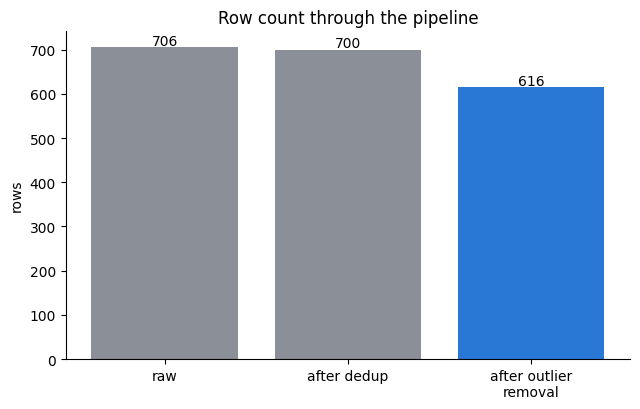

In [42]:
stages = {
    "raw": 706,
    "after dedup": 700,
    "after outlier\nremoval": final_dataset.shape[0],
}

plt.figure(figsize=(6.5, 4.2))
bars = plt.bar(stages.keys(), stages.values(), color=["#8a8f98", "#8a8f98", "#2a78d6"])
plt.ylabel("rows")
plt.title("Row count through the pipeline")
for b in bars:
    plt.text(b.get_x() + b.get_width() / 2, b.get_height() + 5,
              str(int(b.get_height())), ha="center")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

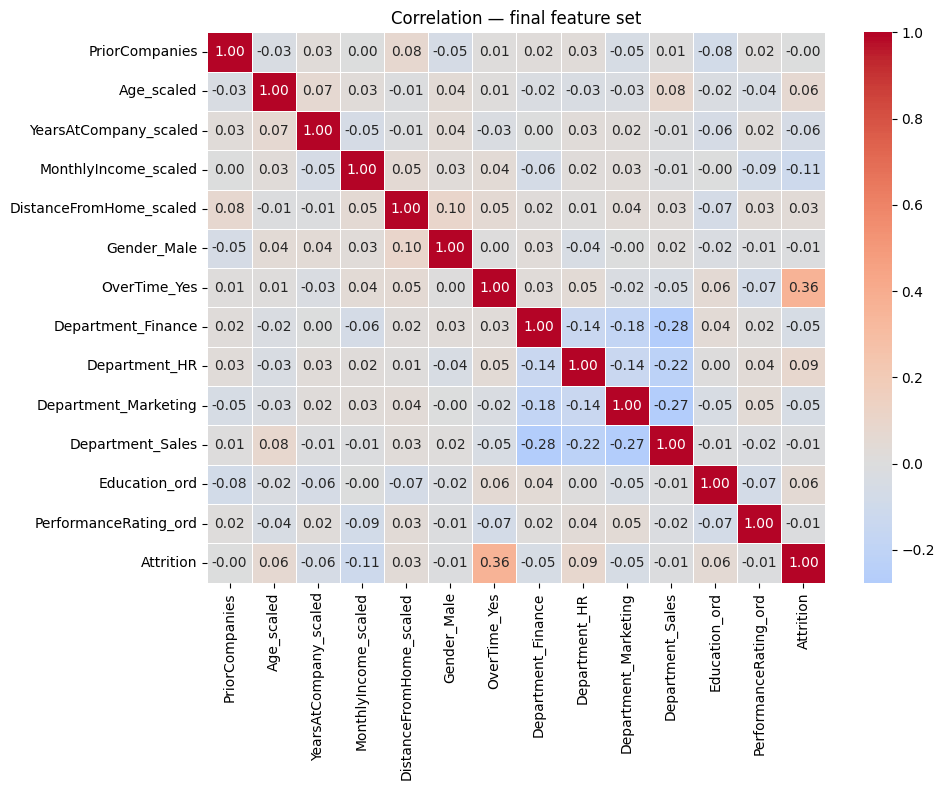

In [43]:
plt.figure(figsize=(10, 8))
sns.heatmap(final_dataset.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5)
plt.title("Correlation — final feature set")
plt.tight_layout()
plt.show()

In [44]:
final_dataset.corr()["Attrition"].sort_values(ascending=False)

Attrition                  1.000000
OverTime_Yes               0.361770
Department_HR              0.086736
Age_scaled                 0.064836
Education_ord              0.056450
DistanceFromHome_scaled    0.034860
PriorCompanies            -0.004357
Gender_Male               -0.010123
PerformanceRating_ord     -0.010904
Department_Sales          -0.011539
Department_Marketing      -0.047225
Department_Finance        -0.049931
YearsAtCompany_scaled     -0.060726
MonthlyIncome_scaled      -0.113386
Name: Attrition, dtype: float64

`OverTime_Yes` correlates with `Attrition` at `0.36` — clearly the
strongest signal here, matching real HR-analytics intuition: employees
who regularly work overtime leave more often. Nothing else comes close
(`MonthlyIncome_scaled` is next, at `-0.11` — higher pay, somewhat less
attrition). Unlike the `loans.csv` project, where `Credit_History`
dominated everything, attrition here doesn't hinge on one obvious
column — a genuinely different, and more realistic, correlation
picture.

## Summary

| Step | What happened | Numbers |
|---|---|---|
| Missing values, numbers (`06`,`07`,`08`) | median fill | `4` columns |
| Duplicates (`17`) | dropped exact repeats | `706 → 700` |
| Inconsistent data (`04` #6) | standardized casing/whitespace | `Gender` one-hot: `8 → 2` cols |
| Missing values, categories (`07`) | mode fill, now safe | `6` columns → `0` missing |
| Fix values/dtype (`18`) | `"3+"` → `3` | `PriorCompanies` → `int64` |
| Outliers (`12`,`13`,`14`) | IQR fence, Z-score cross-checked | `700 → 616` rows |
| Skew fix (`19`) | `log1p` | skew `0.68/1.09 → -0.44/-0.14` |
| Scaling (`15`,`16`) | `StandardScaler` + `MinMaxScaler` | mean≈0/std≈1, min=0/max=1 |
| Encoding (`09`,`10`,`11`) | one-hot, ordinal, label | `5`-category `Department` → `4` cols |
| Final table | dropped `EmployeeID` | `616` rows × `14` columns, all numeric |

Every technique from `04` through `19` ran here, on a dataset built to
actually need all of them — including the two, duplicates and
inconsistent text, that `loans.csv` never had a real example of.
`final_dataset` is ready for a train/test split and a model — the
natural next notebook, not this one.